In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay, 
                             classification_report, accuracy_score, f1_score)
from sklearn.preprocessing import StandardScaler

In [ ]:
TRAIN_PATH_FULL = "../../../data/processed/full_train/train.csv"
TRAIN_PATH_SPLIT = "../../../data/processed/split_85_15/train_85.csv"
TEST_PATH_SPLIT  = "../../../data/processed/split_85_15/test_15.csv"
OUTPUT_PATH="../../../output/svm_classifier/"

OUTPUT_FILE = "x_test_svm_classification.csv"

TARGET_COL = "faulty"
FEATURE = ["trq_margin", "oat", "pa", "np_ng_ratio", "ias", "mgt"]

In [ ]:
# --- FUNZIONE CARICAMENTO ---
def load_dataset(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Errore: Il file al percorso {path} non è stato trovato.")
    df = pd.read_csv(path)
    print(f"Caricato: {path} | Righe: {df.shape[0]} | Colonne: {df.shape[1]}")
    return df

# 1. Caricamento Dati
train_df = load_dataset(TRAIN_PATH_SPLIT)
test_df = load_dataset(TEST_PATH_SPLIT)

# 2. Preparazione Matrici (X) e Target (y)
X_train_raw = train_df[FEATURE].values
y_train = train_df[TARGET_COL].values
X_test_raw = test_df[FEATURE].values
y_test = test_df[TARGET_COL].values

Caricato: C:\Users\valer\Desktop\uni\MAGISTRALE\MANUTENZIONE PREDITTIVA\PROGETTO\train_85.csv | Righe: 631231 | Colonne: 10
Caricato: C:\Users\valer\Desktop\uni\MAGISTRALE\MANUTENZIONE PREDITTIVA\PROGETTO\test_15.csv | Righe: 111394 | Colonne: 10


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# 4. Addestramento Modello SVM
# Usiamo SGDClassifier con loss='hinge' per implementare un'SVM lineare veloce 
# adatto a centinaia di migliaia di righe.
svm_model = SGDClassifier(
    loss='hinge',           # Definisce il comportamento SVM (Linear SVM)
    penalty='l2',           # Regolarizzazione per evitare overfitting
    max_iter=1000, 
    tol=1e-3, 
    random_state=42,
    n_jobs=-1
)

# Se vuoi calcolare le probabilità (per l'AUC), usiamo loss='log_loss' o 
# calibriamo il modello. Per semplicità e velocità usiamo la funzione decisionale.
svm_model.fit(X_train, y_train)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",-1


In [ ]:
# 5. Predizioni e Calcolo Metriche
# Nota: SVM non fornisce "predict_proba" nativamente con 'hinge'. 
# Usiamo decision_function che restituisce la distanza dall'iperpiano.
decision_scores = svm_model.decision_function(X_test)

# Calcolo ROC e AUC
fpr, tpr, thresholds = roc_curve(y_test, decision_scores)
roc_auc = auc(fpr, tpr)

# Calcolo Soglia Ottimale
idx_opt = np.argmax(tpr - fpr)
SOGLIA_OTTIMALE = thresholds[idx_opt]

# Predizioni finali
y_train_pred = svm_model.predict(X_train)
y_test_pred = (svm_model.decision_function(X_test) >= SOGLIA_OTTIMALE).astype(int)

In [ ]:
# 6. Valutazione Performance
acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)
f1_macro_test = f1_score(y_test, y_test_pred, average='macro')

# F1-Score: diverse varianti
f1_binary = f1_score(y_test, y_test_pred) # F1 specifico per la classe positiva (Guasti)
f1_macro = f1_score(y_test, y_test_pred, average='macro') # Media semplice tra le classi
f1_weighted = f1_score(y_test, y_test_pred, average='weighted') # Media pesata sul supporto
print(f"\n--- SVM PERFORMANCE EVALUATION ---")
print(f"ACCURACY  -> Train: {acc_train:.4f} | Test: {acc_test:.4f}")
print(f"F1 MACRO  -> Test: {f1_macro_test:.4f}")
print(f"AUC       -> {roc_auc:.4f}")
print(f"Soglia ottimale (Decision Score): {SOGLIA_OTTIMALE:.4f}")

print(f"F1-SCORE (Guasti) -> {f1_binary:.4f}  <-- Importante per manutenzione")
print(f"F1-SCORE (Macro)  -> {f1_macro:.4f}")
print(f"F1-SCORE (Weight) -> {f1_weighted:.4f}")
print("\nReport di Classificazione:")
print(classification_report(y_test, y_test_pred))


--- SVM PERFORMANCE EVALUATION ---
ACCURACY  -> Train: 0.9351 | Test: 0.9337
F1 MACRO  -> Test: 0.9312
AUC       -> 0.9767
Soglia ottimale (Decision Score): -0.2276
F1-SCORE (Guasti) -> 0.9181  <-- Importante per manutenzione
F1-SCORE (Macro)  -> 0.9312
F1-SCORE (Weight) -> 0.9337

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94     66285
           1       0.92      0.92      0.92     45109

    accuracy                           0.93    111394
   macro avg       0.93      0.93      0.93    111394
weighted avg       0.93      0.93      0.93    111394



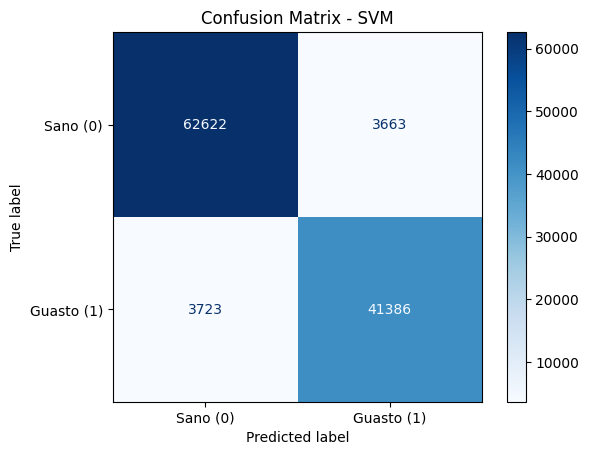

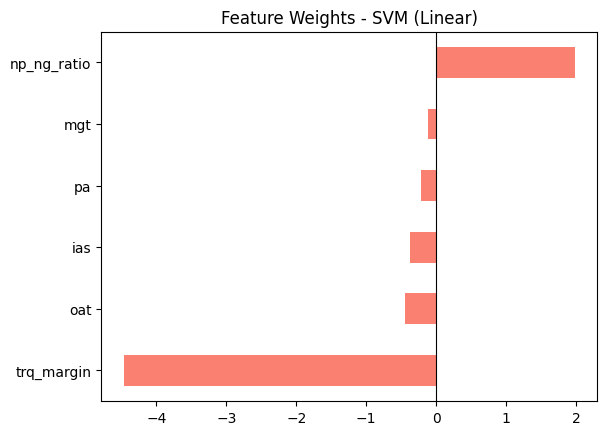

In [ ]:
# 7. Matrice di Confusione
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sano (0)', 'Guasto (1)'])
disp.plot(cmap='Blues', values_format='d') 
plt.title("Confusion Matrix - SVM")
plt.show()

# 8. Salvataggio Risultati
test_df["SVM_Decision_Score"] = decision_scores
test_df["SVM_Predicted_Faulty"] = y_test_pred
test_df.to_csv(OUTPUT_FILE, index=False)

# 9. Interpretazione pesi (Equivalente della Feature Importance per SVM Lineare)
weights = pd.Series(svm_model.coef_[0], index=FEATURE)
weights.sort_values().plot(kind='barh', color='salmon')
plt.title("Feature Weights - SVM (Linear)")
plt.axvline(0, color='black', lw=0.8)
plt.show()

Caricato: C:\Users\valer\Desktop\uni\MAGISTRALE\MANUTENZIONE PREDITTIVA\PROGETTO\train\train_85_full.csv | Righe: 94684
Caricato: C:\Users\valer\Desktop\uni\MAGISTRALE\MANUTENZIONE PREDITTIVA\PROGETTO\test\test_15_full.csv | Righe: 16710

--- SVM PERFORMANCE EVALUATION ---
ACCURACY         -> Train: 0.9346 | Test: 0.9310
AUC              -> 0.9755
CHALLENGE SCORE  -> 0.7652
----------------------------------
F1-SCORE (Guasti) -> 0.9132
F1-SCORE (Macro)  -> 0.9280
F1-SCORE (Weight) -> 0.9309
Soglia ottimale   -> -0.0980

Report di Classificazione:
              precision    recall  f1-score   support

    Sano (0)       0.94      0.95      0.94     10005
  Guasto (1)       0.92      0.90      0.91      6705

    accuracy                           0.93     16710
   macro avg       0.93      0.93      0.93     16710
weighted avg       0.93      0.93      0.93     16710



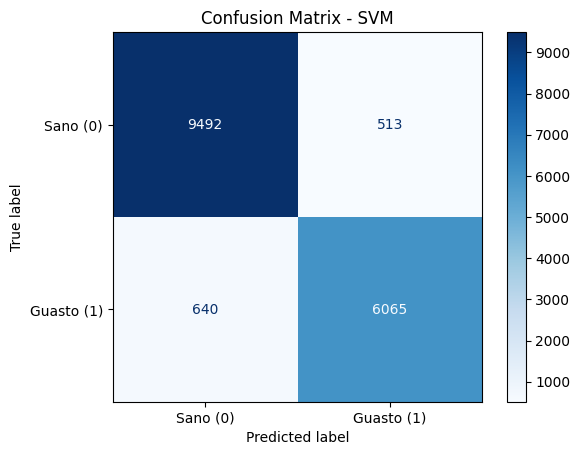

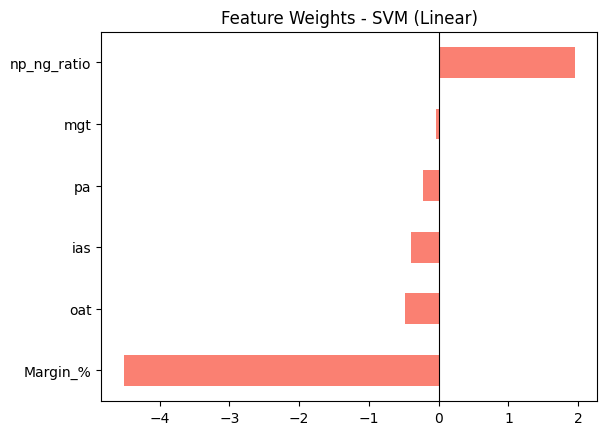


Risultati salvati in: x_test_svm_classification.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay, 
                             classification_report, accuracy_score, f1_score)
from sklearn.preprocessing import StandardScaler


TRAIN_PATH_SPLIT = r"C:\Users\valer\Desktop\uni\MAGISTRALE\MANUTENZIONE PREDITTIVA\PROGETTO\train\train_85_full.csv"
TEST_PATH_SPLIT  = r"C:\Users\valer\Desktop\uni\MAGISTRALE\MANUTENZIONE PREDITTIVA\PROGETTO\test\test_15_full.csv"
OUTPUT_FILE = "x_test_svm_classification.csv"

TARGET_COL = "faulty"
FEATURE = ["Margin_%", "oat", "pa", "np_ng_ratio", "ias", "mgt"]


def calculate_challenge_score(y_true, y_pred, confidences):
  
    scores = []
    for true_label, pred_label, conf in zip(y_true, y_pred, confidences):
        # Validazione input
        if (conf < 0) or (conf > 1) or (pred_label not in [0, 1]):
            scores.append(-100)
            continue
        
        # Inverti confidenza se la predizione è errata
        current_conf = conf if pred_label == true_label else -conf
        
        if true_label == 0:
            # Stato vero: Sano
            score = current_conf
        else:
            # Stato vero: Guasto (Penalità asimmetrica per Falsi Negativi)
            if current_conf >= 0:
                score = current_conf
            else:
                score = 4 * (current_conf ** 11) + 1.0 * current_conf
        scores.append(score)
    
    return np.mean(scores)

def load_dataset(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Errore: Il file {path} non esiste.")
    df = pd.read_csv(path)
    print(f"Caricato: {path} | Righe: {df.shape[0]}")
    return df

train_df = load_dataset(TRAIN_PATH_SPLIT)
test_df = load_dataset(TEST_PATH_SPLIT)


X_train_raw = train_df[FEATURE].values
y_train = train_df[TARGET_COL].values
X_test_raw = test_df[FEATURE].values
y_test = test_df[TARGET_COL].values

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)


svm_model = SGDClassifier(
    loss='hinge', 
    penalty='l2', 
    max_iter=1000, 
    tol=1e-3, 
    random_state=42, 
    n_jobs=-1
)
svm_model.fit(X_train, y_train)

decision_scores = svm_model.decision_function(X_test)

# Calcolo ROC e soglia ottimale (Youden's J statistic)
fpr, tpr, thresholds = roc_curve(y_test, decision_scores)
roc_auc = auc(fpr, tpr)
idx_opt = np.argmax(tpr - fpr)
SOGLIA_OTTIMALE = thresholds[idx_opt]

# Predizioni finali basate sulla soglia
y_test_pred = (decision_scores >= SOGLIA_OTTIMALE).astype(int)
y_train_pred = svm_model.predict(X_train)

# Mappatura dei decision scores in confidenza [0, 1] tramite Sigmoide
confidences = 1 / (1 + np.exp(-np.abs(decision_scores))) 

acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)
f1_binary = f1_score(y_test, y_test_pred) # Focus sulla classe guasto
f1_macro = f1_score(y_test, y_test_pred, average='macro')
f1_weighted = f1_score(y_test, y_test_pred, average='weighted')
challenge_score = calculate_challenge_score(y_test, y_test_pred, confidences)

print(f"\n--- SVM PERFORMANCE EVALUATION ---")
print(f"ACCURACY         -> Train: {acc_train:.4f} | Test: {acc_test:.4f}")
print(f"AUC              -> {roc_auc:.4f}")
print(f"CHALLENGE SCORE  -> {challenge_score:.4f}")
print(f"----------------------------------")
print(f"F1-SCORE (Guasti) -> {f1_binary:.4f}")
print(f"F1-SCORE (Macro)  -> {f1_macro:.4f}")
print(f"F1-SCORE (Weight) -> {f1_weighted:.4f}")
print(f"Soglia ottimale   -> {SOGLIA_OTTIMALE:.4f}")

print("\nReport di Classificazione:")
print(classification_report(y_test, y_test_pred, target_names=['Sano (0)', 'Guasto (1)']))

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sano (0)', 'Guasto (1)'])
disp.plot(cmap='Blues', values_format='d') 
plt.title("Confusion Matrix - SVM")
plt.show()

# Interpretazione pesi (Feature Importance)
weights = pd.Series(svm_model.coef_[0], index=FEATURE)
weights.sort_values().plot(kind='barh', color='salmon')
plt.title("Feature Weights - SVM (Linear)")
plt.axvline(0, color='black', lw=0.8)
plt.show()

# --- 8. SALVATAGGIO ---
test_df["SVM_Decision_Score"] = decision_scores
test_df["SVM_Confidence"] = confidences
test_df["SVM_Predicted_Faulty"] = y_test_pred
test_df.to_csv(OUTPUT_FILE, index=False)
print(f"\nRisultati salvati in: {OUTPUT_FILE}")

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from pathlib import Path

def dividi_dataset_manutenzione(path_input):
    # Trasformiamo il percorso in un oggetto Path (gestisce meglio i path Windows)
    file_path = Path(path_input)
    
    if not file_path.exists():
        print(f"Errore: Il file non esiste in {file_path}")
        return

    # 1. Caricamento
    print(f"Caricamento di: {file_path.name}...")
    df = pd.read_csv(file_path)
    
    # 2. Split (85% Train, 15% Test)
    # random_state=42 garantisce la riproducibilità dei risultati
    train_df, test_df = train_test_split(df, train_size=0.85, random_state=42)
    
    # 3. Definizione percorsi di output nella stessa cartella
    cartella_output = file_path.parent
    path_train = cartella_output / "train_85_full.csv"
    path_test = cartella_output / "test_15_full.csv"
    
    # 4. Salvataggio
    train_df.to_csv(path_train, index=False)
    test_df.to_csv(path_test, index=False)
    
    print("-" * 30)
    print(f"Divisione completata con successo!")
    print(f"Righe totali: {len(df)}")
    print(f"Training set (85%): {len(train_df)} righe -> Salvato in: {path_train}")
    print(f"Test set (15%): {len(test_df)} righe -> Salvato in: {path_test}")

# Esecuzione
percorso = r"C:\Users\valer\Desktop\uni\MAGISTRALE\MANUTENZIONE PREDITTIVA\PROGETTO\test\x_test_with_predictions.csv"
dividi_dataset_manutenzione(percorso)

Caricamento di: x_test_with_predictions.csv...
------------------------------
Divisione completata con successo!
Righe totali: 111394
Training set (85%): 94684 righe -> Salvato in: C:\Users\valer\Desktop\uni\MAGISTRALE\MANUTENZIONE PREDITTIVA\PROGETTO\test\train_85_full.csv
Test set (15%): 16710 righe -> Salvato in: C:\Users\valer\Desktop\uni\MAGISTRALE\MANUTENZIONE PREDITTIVA\PROGETTO\test\test_15_full.csv



===== CLASSIFICATION RESULTS =====
AUC: 0.9760
Accuracy: 0.9370
F1: 0.9218
Soglia ottimale: -0.1675

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     66481
           1       0.92      0.92      0.92     44913

    accuracy                           0.94    111394
   macro avg       0.93      0.93      0.93    111394
weighted avg       0.94      0.94      0.94    111394



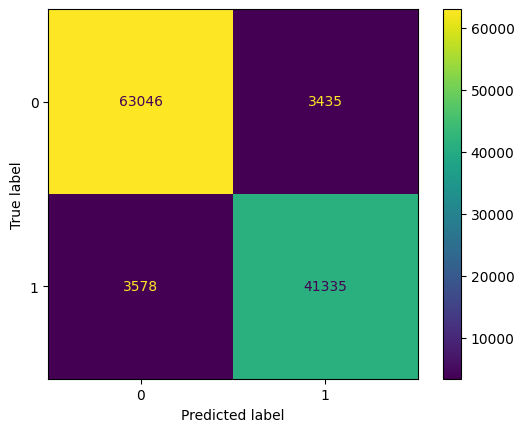

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

FILE_PATH = "test_regression_output.csv"
TARGET_COL = "faulty"

FEATURES = [
    "Margin_Pred_Mean",
    "Margin_Pred_Std",
    "Prob_Fault_Bayes",
    "oat",
    "pa",
    "np_ng_ratio",
    "ias",
    "mgt"
]

df = pd.read_csv(FILE_PATH)

X = df[FEATURES].values
y = df[TARGET_COL].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

svm_model = SGDClassifier(
    loss='hinge',
    penalty='l2',
    max_iter=1000,
    tol=1e-3,
    random_state=42
)

svm_model.fit(X_scaled, y)

decision_scores = svm_model.decision_function(X_scaled)

# ROC
fpr, tpr, thresholds = roc_curve(y, decision_scores)
roc_auc = auc(fpr, tpr)

idx_opt = np.argmax(tpr - fpr)
SOGLIA = thresholds[idx_opt]

y_pred = (decision_scores >= SOGLIA).astype(int)

confidences = 1 / (1 + np.exp(-np.abs(decision_scores)))

acc = accuracy_score(y, y_pred)
f1 = f1_score(y, y_pred)

print("\n===== CLASSIFICATION RESULTS =====")
print(f"AUC: {roc_auc:.4f}")
print(f"Accuracy: {acc:.4f}")
print(f"F1: {f1:.4f}")
print(f"Soglia ottimale: {SOGLIA:.4f}")

print("\nClassification Report:")
print(classification_report(y, y_pred))

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()


Best Threshold (Bayes): 0.9246231155778895

===== BAYESIAN PURE RESULTS =====
AUC: 0.8759
Accuracy: 0.8556
F1: 0.8301
Challenge Score: 0.2594

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.84      0.87     66481
           1       0.79      0.88      0.83     44913

    accuracy                           0.86    111394
   macro avg       0.85      0.86      0.85    111394
weighted avg       0.86      0.86      0.86    111394



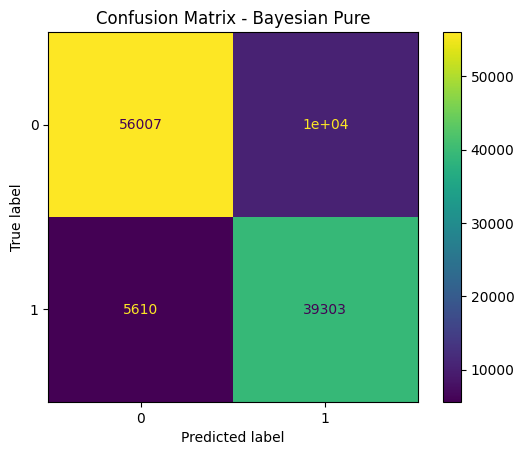

0.8759457745957688

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.metrics import roc_auc_score

FILE_PATH = "test_regression_output.csv"
TARGET_COL = "faulty"

# Soglia tecnica sul margin (definita ingegneristicamente)
MARGIN_THRESHOLD = 0  # %

df = pd.read_csv(FILE_PATH)

y = df[TARGET_COL].values
mu = df["Trq_Target_Pred"].values
sigma = df["Trq_Target_Std"].values
t_m = df["trq_measured"].values

# ============================================================
# 1️⃣ PROPAGAZIONE ANALITICA DELL'INCERTEZZA (Delta Method)
# ============================================================

margin_mean = (t_m - mu) / mu * 100
margin_std = np.abs((t_m / (mu**2)) * 100) * sigma

# ============================================================
# 2️⃣ PROBABILITÀ DI GUASTO
# ============================================================

z = (MARGIN_THRESHOLD - margin_mean) / (margin_std + 1e-8)

# Se il guasto è margin > soglia:
#prob_fault = 1 - norm.cdf(z)
prob_fault = norm.cdf(z)

# ============================================================
# 3️⃣ OTTIMIZZAZIONE SOGLIA DECISIONALE (Challenge Score)
# ============================================================

def calculate_challenge_score(y_true, y_pred, confidences):
    scores = []
    for true_label, pred_label, conf in zip(y_true, y_pred, confidences):
        current_conf = conf if pred_label == true_label else -conf
        if true_label == 0:
            score = current_conf
        else:
            if current_conf >= 0:
                score = current_conf
            else:
                score = 4 * (current_conf ** 11) + current_conf
        scores.append(score)
    return np.mean(scores)

best_score = -np.inf
best_threshold = 0

for t in np.linspace(0, 1, 200):
    y_tmp = (prob_fault >= t).astype(int)
    score = calculate_challenge_score(y, y_tmp, prob_fault)
    if score > best_score:
        best_score = score
        best_threshold = t

print("Best Threshold (Bayes):", best_threshold)

# ============================================================
# 4️⃣ CLASSIFICAZIONE FINALE
# ============================================================

y_pred = (prob_fault >= best_threshold).astype(int)

acc = accuracy_score(y, y_pred)
f1 = f1_score(y, y_pred)
roc_auc = auc(*roc_curve(y, prob_fault)[:2])

print("\n===== BAYESIAN PURE RESULTS =====")
print(f"AUC: {roc_auc:.4f}")
print(f"Accuracy: {acc:.4f}")
print(f"F1: {f1:.4f}")
print(f"Challenge Score: {best_score:.4f}")

print("\nClassification Report:")
print(classification_report(y, y_pred))

cm = confusion_matrix(y, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix - Bayesian Pure")
plt.show()

roc_auc_score(y, prob_fault)



     SVM FINAL RESULTS (15% TEST SET)
AUC:      0.9764
Accuracy: 0.9373
F1 Score: 0.9218
Soglia Ottimale: -0.2688

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95     66481
           1       0.93      0.92      0.92     44913

    accuracy                           0.94    111394
   macro avg       0.94      0.93      0.93    111394
weighted avg       0.94      0.94      0.94    111394



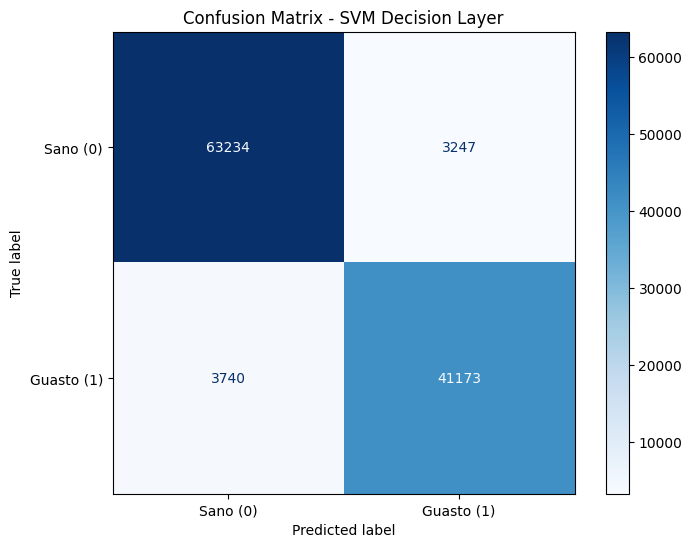

C:\Users\valer\AppData\Local\Temp\ipykernel_116824\3002386266.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=TARGET_COL, y="trq_margin", data=df, palette="Set2")


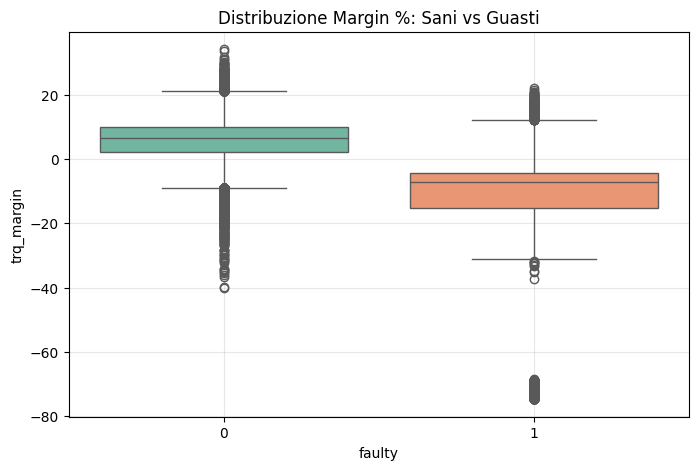

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_curve, auc, confusion_matrix, 
                             ConfusionMatrixDisplay, classification_report, 
                             accuracy_score, f1_score)

# ============================================================
# 1. CARICAMENTO DATI
# ============================================================
#FILE_PATH = "test_regression_output.csv"
FILE_PATH = "dataset_for_classification.csv"
TARGET_COL = "faulty"

df = pd.read_csv(FILE_PATH)

# Feature richieste: includono i parametri fisici e quelli Bayesiani
FEATURES = [
    "Margin_Pred_Mean",
    "Margin_Pred_Std",
    "oat",
    "pa",
    "np_ng_ratio",
    "ias",
    "mgt"
]
 #"Prob_Fault_Bayes", # <--- La probabilità calcolata dalla PDF (Richiesta Prof)
X = df[FEATURES].values
y = df[TARGET_COL].values

# ============================================================
# 2. DIVISIONE TRAIN/TEST (85% / 15%)
# ============================================================
# Fondamentale per dimostrare che il modello funziona su dati nuovi
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# ============================================================
# 3. SCALING (Basato solo sul Train per evitare leakage)
# ============================================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# ============================================================
# 4. MODELLO SVM (SGD con Hinge Loss)
# ============================================================
svm_model = SGDClassifier(
    loss="hinge",
    penalty="l2",
    max_iter=1000,
    tol=1e-3,
    random_state=42
)

svm_model.fit(X_train, y_train)

# Calcolo degli score decisionali (distanza dall'iperpiano)
decision_scores = svm_model.decision_function(X_test)

# ============================================================
# 5. OTTIMIZZAZIONE SOGLIA (Punto di Youden su ROC)
# ============================================================
fpr, tpr, thresholds = roc_curve(y_test, decision_scores)
roc_auc = auc(fpr, tpr)

# Troviamo la soglia che massimizza (True Positive Rate - False Positive Rate)
idx_opt = np.argmax(tpr - fpr)
best_threshold = thresholds[idx_opt]

# Predizione finale basata sulla soglia ottimale
y_pred = (decision_scores >= best_threshold).astype(int)

# Trasformiamo la distanza in una "confidenza" (0-1) usando la Sigmoide
confidences = 1 / (1 + np.exp(-np.abs(decision_scores)))

# ============================================================
# 6. RISULTATI E VISUALIZZAZIONE
# ============================================================
print("\n" + "="*30)
print("     SVM FINAL RESULTS (15% TEST SET)")
print("="*30)
print(f"AUC:      {roc_auc:.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"Soglia Ottimale: {best_threshold:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Sano (0)", "Guasto (1)"])
disp.plot(cmap="Blues", ax=ax)
plt.title("Confusion Matrix - SVM Decision Layer")
plt.show()

# Plot Boxplot per verifica fisica del margine
plt.figure(figsize=(8, 5))
sns.boxplot(x=TARGET_COL, y="trq_margin", data=df, palette="Set2")
plt.title("Distribuzione Margin %: Sani vs Guasti")
plt.grid(True, alpha=0.3)
plt.show()


===== SVM RESULTS =====
AUC:      0.9764
Accuracy: 0.9365
F1 Score: 0.9192

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.95     66481
           1       0.94      0.89      0.92     44913

    accuracy                           0.94    111394
   macro avg       0.94      0.93      0.93    111394
weighted avg       0.94      0.94      0.94    111394



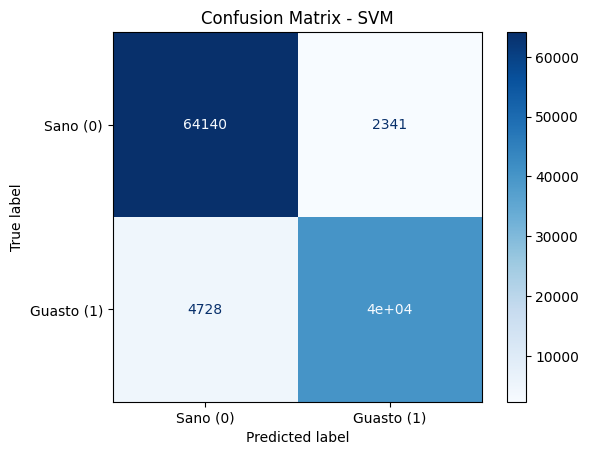

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_curve, auc, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report,
                             accuracy_score, f1_score)

# ============================================================
# LOAD DATASET COMPLETO
# ============================================================
FILE_PATH = r"C:\Users\valer\Desktop\uni\MAGISTRALE\MANUTENZIONE PREDITTIVA\PROGETTO\dataset_for_classification.csv"
TARGET_COL = "faulty"

df = pd.read_csv(FILE_PATH)

FEATURES = [
    "Margin_Pred_Mean",
    "Margin_Pred_Std",
    "oat",
    "pa",
    "np_ng_ratio",
    "ias",
    "mgt"
]

X = df[FEATURES].values
y = df[TARGET_COL].values

# ============================================================
# SPLIT 85% TRAIN - 15% TEST
# ============================================================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# ============================================================
# SCALING (NO LEAKAGE)
# ============================================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# ============================================================
# SVM LINEARE (SGD)
# ============================================================
svm_model = SGDClassifier(
    loss="hinge",
    penalty="l2",
    max_iter=1000,
    tol=1e-3,
    random_state=42
)

svm_model.fit(X_train, y_train)

decision_scores = svm_model.decision_function(X_test)

# ============================================================
# ROC & METRICHE
# ============================================================
fpr, tpr, thresholds = roc_curve(y_test, decision_scores)
roc_auc = auc(fpr, tpr)

# Soglia standard = 0 (iperpiano SVM)
y_pred = (decision_scores >= 0).astype(int)

print("\n===== SVM RESULTS =====")
print(f"AUC:      {roc_auc:.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ============================================================
# CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Sano (0)", "Guasto (1)"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - SVM")
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier # Passiamo a SVC per maggior precisione
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_curve, auc, confusion_matrix, 
                             ConfusionMatrixDisplay, classification_report, 
                             accuracy_score, f1_score)

# ============================================================
# LOAD & PREPARE TARGET
# ============================================================
FILE_PATH = "dataset_for_classification.csv"
df = pd.read_csv(FILE_PATH)

# --- PSEUDO-LABELING ---
# Se non hai la colonna 'faulty', la creiamo basandoci sulla fisica del motore
# Soglia suggerita: -3% (regolabile in base ai tuoi requisiti di manutenzione)
THRESHOLD_FAULT = -3.0
df['faulty'] = (df['Margin_Pred_Mean'] <= THRESHOLD_FAULT).astype(int)

print(f"Distribuzione classi generata:\n{df['faulty'].value_counts()}")

FEATURES = [
    "Margin_Pred_Mean",
    "Margin_Pred_Std",
    "oat",
    "pa",
    "np_ng_ratio",
    "ias",
    "mgt"
]

X = df[FEATURES].values
y = df["faulty"].values

# ============================================================
# SPLIT & SCALING
# ============================================================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# ============================================================
# SVM CON KERNEL RBF (Più precisa di SGD lineare)
# ============================================================
# Usiamo probability=True per avere i punteggi per la curva ROC
svm_model = SGDClassifier(
    loss="hinge",
    penalty="l2",
    max_iter=1000,
    tol=1e-3,
    random_state=42
)

svm_model.fit(X_train, y_train)
# Predizioni e Score
y_pred = svm_model.predict(X_test)
probs = svm_model.predict_proba(X_test)[:, 1] # Probabilità della classe 'Guasto'

# ============================================================
# METRICHE E ROC
# ============================================================
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

print("\n" + "="*30)
print("     SVM CLASSIFICATION      ")
print("="*30)
print(f"AUC:      {roc_auc:.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print("\nReport di Classificazione:")
print(classification_report(y_test, y_pred, target_names=["Sano", "Guasto"]))

# ============================================================
# PLOT ROC CURVE
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM Classifier')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()

# ============================================================
# CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Sano (0)", "Guasto (1)"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - SVM")
plt.show()

Distribuzione classi generata:
faulty
0    459032
1    283593
Name: count, dtype: int64


AttributeError: This 'SGDClassifier' has no attribute 'predict_proba'


      SVM RBF + YOUDEN THRESHOLD RESULTS
AUC:             0.9764
Soglia Ottimale: -0.2688
Accuracy:        0.9373
F1 Score:        0.9218

Classification Report (Soglia Ottimale):
              precision    recall  f1-score   support

        Sano       0.94      0.95      0.95     66481
      Guasto       0.93      0.92      0.92     44913

    accuracy                           0.94    111394
   macro avg       0.94      0.93      0.93    111394
weighted avg       0.94      0.94      0.94    111394



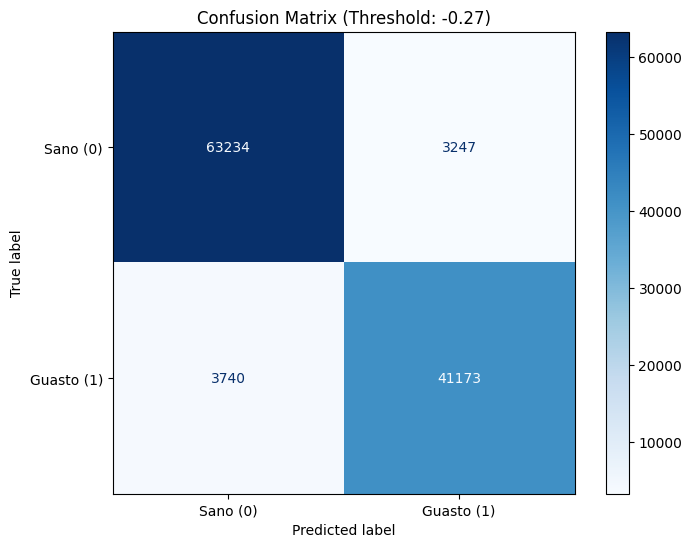

C:\Users\valer\AppData\Local\Temp\ipykernel_239676\112151720.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=TARGET_COL, y="Margin_Pred_Mean", data=df, palette="coolwarm")


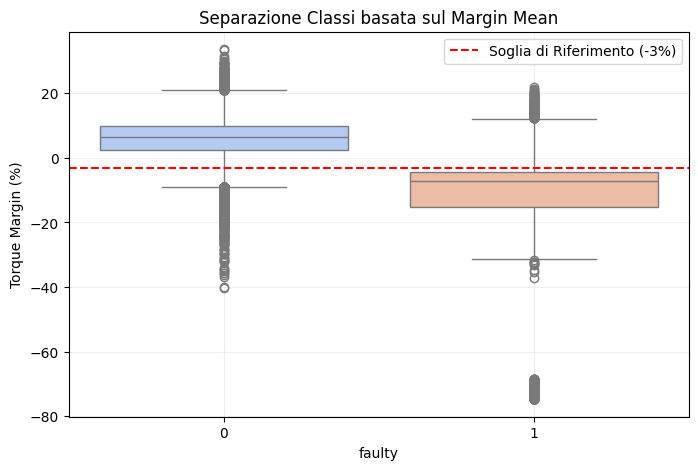

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_curve, auc, confusion_matrix, 
                             ConfusionMatrixDisplay, classification_report, 
                             accuracy_score, f1_score)

# ============================================================
# 1. CARICAMENTO E PREPARAZIONE TARGET (PSEUDO-LABELING)
# ============================================================
FILE_PATH = "dataset_for_classification.csv"
df = pd.read_csv(FILE_PATH)

# Se la colonna 'faulty' non esiste, la creiamo basandoci sulla fisica
# Usiamo la soglia del -3% identificata precedentemente come critica
TARGET_COL = "faulty"
if TARGET_COL not in df.columns:
    df[TARGET_COL] = (df["Margin_Pred_Mean"] <= -3.0).astype(int)

# Feature per la classificazione
FEATURES = [
    "Margin_Pred_Mean",
    "Margin_Pred_Std",
    "oat",
    "pa",
    "np_ng_ratio",
    "ias",
    "mgt"
]

X = df[FEATURES].values
y = df[TARGET_COL].values

# ============================================================
# 2. DIVISIONE TRAIN/TEST (85% / 15%)
# ============================================================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# ============================================================
# 3. SCALING (No Data Leakage)
# ============================================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# ============================================================
# 4. MODELLO SVM CON KERNEL RBF
# ============================================================
# Usiamo SVC con kernel RBF e abilitiamo probability per la curva ROC
svm_model = SGDClassifier(
    loss="hinge",
    penalty="l2",
    max_iter=1000,
    tol=1e-3,
    random_state=42
)

svm_model.fit(X_train, y_train)

# Otteniamo i punteggi decisionali (distanza dall'iperpiano)
decision_scores = svm_model.decision_function(X_test)

# ============================================================
# 5. OTTIMIZZAZIONE SOGLIA (Indice di Youden)
# ============================================================
fpr, tpr, thresholds = roc_curve(y_test, decision_scores)
roc_auc = auc(fpr, tpr)

# Calcolo indice di Youden: J = TPR - FPR
idx_opt = np.argmax(tpr - fpr)
best_threshold = thresholds[idx_opt]

# Predizione basata sulla soglia ottimale invece dello 0 standard
y_pred_opt = (decision_scores >= best_threshold).astype(int)

# ============================================================
# 6. REPORT E VISUALIZZAZIONE
# ============================================================
print("\n" + "="*40)
print("      SVM RBF + YOUDEN THRESHOLD RESULTS")
print("="*40)
print(f"AUC:             {roc_auc:.4f}")
print(f"Soglia Ottimale: {best_threshold:.4f}")
print(f"Accuracy:        {accuracy_score(y_test, y_pred_opt):.4f}")
print(f"F1 Score:        {f1_score(y_test, y_pred_opt):.4f}")

print("\nClassification Report (Soglia Ottimale):")
print(classification_report(y_test, y_pred_opt, target_names=["Sano", "Guasto"]))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Sano (0)", "Guasto (1)"])
disp.plot(cmap="Blues", ax=ax)
plt.title(f"Confusion Matrix (Threshold: {best_threshold:.2f})")
plt.show()

# Boxplot di Verifica Fisica
plt.figure(figsize=(8, 5))
sns.boxplot(x=TARGET_COL, y="Margin_Pred_Mean", data=df, palette="coolwarm")
plt.axhline(-3.0, color='red', linestyle='--', label='Soglia di Riferimento (-3%)')
plt.title("Separazione Classi basata sul Margin Mean")
plt.ylabel("Torque Margin (%)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_curve, auc, confusion_matrix, 
                             ConfusionMatrixDisplay, classification_report, 
                             accuracy_score, f1_score)


FILE_PATH = "dataset_for_classification.csv"
TARGET_COL = "faulty"

df = pd.read_csv(FILE_PATH)

# CREAZIONE TARGET 
if TARGET_COL not in df.columns:
    # Usiamo la soglia critica del -3.0% 
    df[TARGET_COL] = (df["Margin_Pred_Mean"] <= -3.0).astype(int)

FEATURES = [
    "Margin_Pred_Mean",
    "Margin_Pred_Std",
    "oat",
    "pa",
    "np_ng_ratio",
    "ias",
    "mgt"
]

X = df[FEATURES].values
y = df[TARGET_COL].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# SCALING per evitare data leakage
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)


svm_model = SGDClassifier(
    loss="hinge",
    penalty="l2",
    max_iter=1000,
    tol=1e-3,
    random_state=42
)

svm_model.fit(X_train, y_train)

# Calcolo degli score decisionali (distanza dall'iperpiano)
decision_scores = svm_model.decision_function(X_test)

#SOGLIA DI YOUDEN
fpr, tpr, thresholds = roc_curve(y_test, decision_scores)
roc_auc = auc(fpr, tpr)

# Troviamo la soglia che massimizza (True Positive Rate - False Positive Rate),
# Questo punto sulla ROC è quello che bilancia meglio sensibilità e specificità
idx_opt = np.argmax(tpr - fpr)
best_threshold = thresholds[idx_opt]

# Predizione finale basata sulla soglia ottimale
y_pred = (decision_scores >= best_threshold).astype(int)

# Trasformiamo la distanza in una "confidenza" (0-1) usando la Sigmoide
confidences = 1 / (1 + np.exp(-np.abs(decision_scores)))

# CALCOLO SCORE CHALLENGE
def challenge_score(true_label, pred_label, confidence):

    # check confidence range
    if (confidence < 0) or (confidence > 1):
        return -100

    # check pred label
    if pred_label not in [0, 1]:
        return -100

    # invert confidence if prediction is wrong
    if pred_label != true_label:
        confidence = -confidence

    # true state healthy
    if true_label == 0:
        score = confidence

    # true state faulty
    else:
        if confidence >= 0:
            score = confidence
        else:
            score = 4 * confidence**11 + confidence

    return score


scores = []

for true, pred, conf in zip(y_test, y_pred, confidences):
    s = challenge_score(true, pred, conf)
    scores.append(s)

scores = np.array(scores)

mean_score = np.mean(scores)
total_score = np.sum(scores)

print("\n" + "="*40)
print("       CHALLENGE SCORING")
print("="*40)
print(f"Mean Score:   {mean_score:.4f}")
print(f"Total Score:  {total_score:.2f}")

plt.figure(figsize=(8,5))
sns.histplot(scores, bins=50)
plt.title("Distribuzione Challenge Score")
plt.xlabel("Score")
plt.ylabel("Frequenza")
plt.grid(True, alpha=0.3)
plt.show()

print("Min score:", np.min(scores))
print("Max score:", np.max(scores))

# RISULTATI E PLOT 
print("\n" + "="*40)
print("     SVM FINAL RESULTS (15% TEST SET)")
print("="*40)
print(f"AUC:              {roc_auc:.4f}")
print(f"Accuracy:         {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score:         {f1_score(y_test, y_pred):.4f}")
print(f"Soglia Ottimale:  {best_threshold:.4f}")

print("\nClassification Report (Soglia di Youden):")
print(classification_report(y_test, y_pred, target_names=["Sano", "Guasto"]))


fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Sano", "Guasto"])
disp.plot(cmap="Blues", ax=ax)
plt.title(f"Confusion Matrix - SVM")
plt.show()


plt.figure(figsize=(8, 5))
sns.boxplot(x=TARGET_COL, y="Margin_Pred_Mean", data=df, palette="Set2")
plt.axhline(-3.0, color='red', linestyle='--', label='Soglia Fisica (-3%)')
plt.title("Verifica Fisica: Distribuzione Margine Predetto")
plt.ylabel("Torque Margin (%)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

KeyError: "['Margin_Pred_Mean', 'Margin_Pred_Std'] not in index"

NUOVA PIPELINE


 RISULTATI SU: TEST 15% (MARGINE REALE)
Accuracy:      0.9333
F1 Score:      0.9171
Total PHM Score: 85082.60
Mean Score: 0.7638


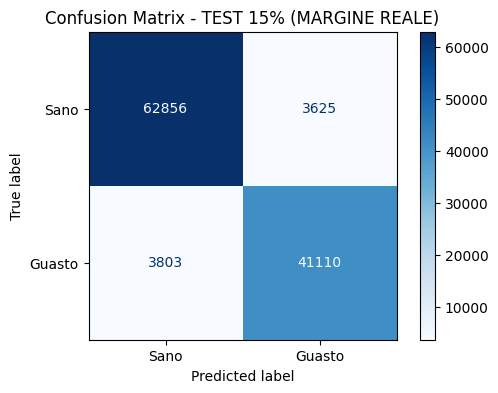


 RISULTATI SU: TEST 15% (MARGINE PREDETTO)
Accuracy:      0.9329
F1 Score:      0.9166
Total PHM Score: 85004.87
Mean Score: 0.7631


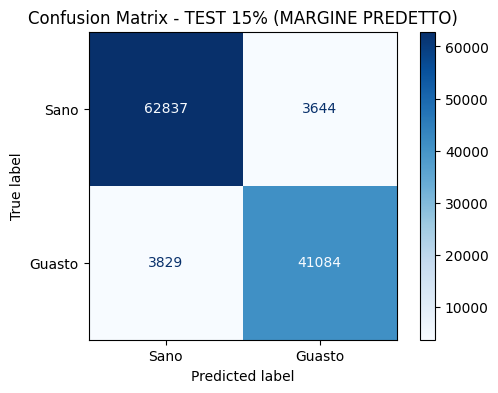

In [ ]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_curve, auc, confusion_matrix, 
                             ConfusionMatrixDisplay, classification_report, 
                             accuracy_score, f1_score)

BASE_PATH = r"C:\Users\valer\Desktop\uni\MAGISTRALE\MANUTENZIONE PREDITTIVA\PROGETTO"

TRAIN_PATH_85 = os.path.join(BASE_PATH, "train", "train_85.csv")
TEST_PATH_15  = os.path.join(BASE_PATH, "test", "test_15.csv")
REGRESSOR_OUTPUT_PATH = os.path.join(BASE_PATH, "pred_margin_test_bayesian.csv")

train_df = pd.read_csv(TRAIN_PATH_85)
test_df_real = pd.read_csv(TEST_PATH_15)
test_df_predict = pd.read_csv(REGRESSOR_OUTPUT_PATH)

TARGET_COL = "faulty"

FEATURES_REAL = ["trq_margin", "oat", "pa", "np_ng_ratio", "ias", "mgt"]
FEATURES_PRED = ["trq_margin_pred", "oat", "pa", "np_ng_ratio", "ias", "mgt"]

X_train = train_df[FEATURES_REAL].values
y_train = train_df[TARGET_COL].values

X_test_real = test_df_real[FEATURES_REAL].values
y_test_real = test_df_real[TARGET_COL].values

X_test_predict = test_df_predict[FEATURES_PRED].values
y_test_predict = test_df_predict[TARGET_COL].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_test_real_scaled = scaler.transform(X_test_real)
X_test_predict_scaled = scaler.transform(X_test_predict)

svm_model = SGDClassifier(loss="hinge", penalty="l2", random_state=42)
svm_model.fit(X_train_scaled, y_train)

def challenge_score(true_label, pred_label, confidence):

    if (confidence < 0) or (confidence > 1):
        return -100

    if pred_label not in [0, 1]:
        return -100

    if pred_label != true_label:
        confidence = -confidence

    if true_label == 0:
        return confidence
    
    else:
        if confidence >= 0:
            return confidence
        else:
            return 4 * confidence ** 11 + 1.0 * confidence

def evaluate_model(X_eval, y_eval, name):
    # Ottenimento dei decision scores (distanza dall'iperpiano)
    decision_scores = svm_model.decision_function(X_eval)
    
    # Calcolo soglia di Youden (Ottimizzazione sulla curva ROC)
    fpr, tpr, thresholds = roc_curve(y_eval, decision_scores)
    idx_opt = np.argmax(tpr - fpr)
    best_threshold = thresholds[idx_opt]
    
    # Predizione basata sulla soglia ottimale
    y_pred = (decision_scores >= best_threshold).astype(int)
    
    # Calcolo confidenza tramite funzione sigmoidea applicata alla distanza
    confidences = 1 / (1 + np.exp(-np.abs(decision_scores)))
    
    # Calcolo degli score individuali e totali
    scores = [challenge_score(t, p, c) for t, p, c in zip(y_eval, y_pred, confidences)]
    mean_score = np.mean(scores)

    print(f"\n" + "="*50)
    print(f" RISULTATI SU: {name}")
    print("="*50)
    print(f"Accuracy:      {accuracy_score(y_eval, y_pred):.4f}")
    print(f"F1 Score:      {f1_score(y_eval, y_pred):.4f}")
    print(f"Total PHM Score: {np.sum(scores):.2f}")
    print(f"Mean Score: {mean_score:.4f}")
    
    
    fig, ax = plt.subplots(figsize=(6, 4))
    ConfusionMatrixDisplay.from_predictions(y_eval, y_pred, 
                                            display_labels=["Sano", "Guasto"], 
                                            cmap="Blues", ax=ax, values_format='d')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()


# FASE DI TEST 
# Test 1: su dati reali (test_15.csv)
evaluate_model(X_test_real_scaled, y_test_real, "TEST 15% (MARGINE REALE)")

# Test 2: Su output del regressore (pred_margin_test_bayesian.csv)
evaluate_model(X_test_predict_scaled, y_test_predict, "TEST 15% (MARGINE PREDETTO)")

SENZA SOGLIA DI YOUDEN


 RISULTATI SU: TEST 15% (MARGINE REALE)
Accuracy:        0.9341
F1 Score:        0.9166
Total PHM Score: 85172.98
Mean Score:      0.7646


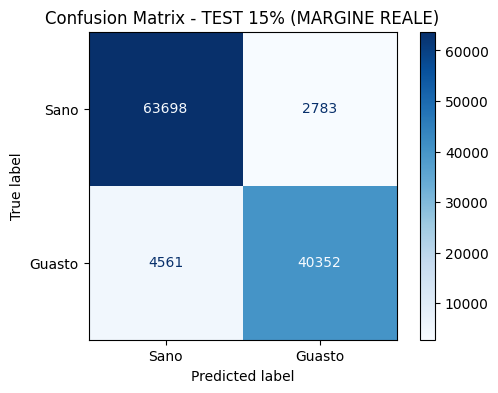


 RISULTATI SU: TEST 15% (MARGINE PREDETTO)
Accuracy:        0.9337
F1 Score:        0.9161
Total PHM Score: 85101.17
Mean Score:      0.7640


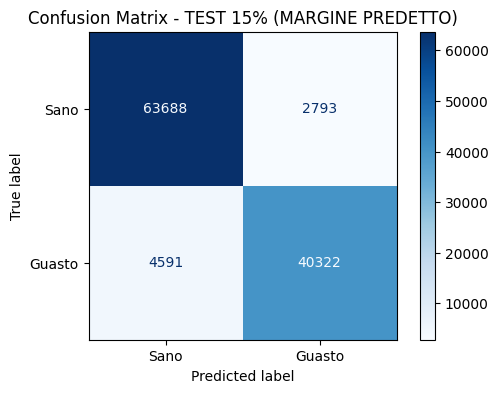

In [ ]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, 
                             classification_report, accuracy_score, f1_score)

BASE_PATH = r"C:\Users\valer\Desktop\uni\MAGISTRALE\MANUTENZIONE PREDITTIVA\PROGETTO"

TRAIN_PATH_85 = os.path.join(BASE_PATH, "train", "train_85.csv")
TEST_PATH_15  = os.path.join(BASE_PATH, "test", "test_15.csv")
REGRESSOR_OUTPUT_PATH = os.path.join(BASE_PATH, "pred_margin_test_bayesian2.csv")

train_df = pd.read_csv(TRAIN_PATH_85)
test_df_real = pd.read_csv(TEST_PATH_15)
test_df_predict = pd.read_csv(REGRESSOR_OUTPUT_PATH)

TARGET_COL = "faulty"

FEATURES_REAL = ["trq_margin", "oat", "pa", "np_ng_ratio", "ias", "mgt"]
FEATURES_PRED = ["trq_margin_pred", "oat", "pa", "np_ng_ratio", "ias", "mgt"]


X_train = train_df[FEATURES_REAL].values
y_train = train_df[TARGET_COL].values

X_test_real = test_df_real[FEATURES_REAL].values
y_test_real = test_df_real[TARGET_COL].values

X_test_predict = test_df_predict[FEATURES_PRED].values
y_test_predict = test_df_predict[TARGET_COL].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_test_real_scaled = scaler.transform(X_test_real)
X_test_predict_scaled = scaler.transform(X_test_predict)

svm_model = SGDClassifier(loss="hinge", penalty="l2", random_state=42)
svm_model.fit(X_train_scaled, y_train)

# SCORE CHALLENGE
def challenge_score(true_label, pred_label, confidence):
    
    if (confidence < 0) or (confidence > 1): 
        return -100
    
    # Inversione segno confidenza se la predizione è errata
    c_signed = confidence if pred_label == true_label else -confidence
    
    if true_label == 0:
        # caso sano
        return c_signed
    else:
        # caso guasto
        if c_signed >= 0:
            return c_signed
        else:
        
            return 4 * (c_signed ** 11) + 1.0 * c_signed

def evaluate_model(X_eval, y_eval, name):
    y_pred = svm_model.predict(X_eval)
    
    # Calcolo della confidenza tramite distanza dall'iperpiano (decision_function)
    # Trasformata in range [0, 1] tramite sigmoide
    decision_scores = svm_model.decision_function(X_eval)
    confidences = 1 / (1 + np.exp(-np.abs(decision_scores)))
    
    scores = [challenge_score(t, p, c) for t, p, c in zip(y_eval, y_pred, confidences)]
    
    print(f"\n" + "="*50)
    print(f" RISULTATI SU: {name}")
    print("="*50)
    print(f"Accuracy:        {accuracy_score(y_eval, y_pred):.4f}")
    print(f"F1 Score:        {f1_score(y_eval, y_pred):.4f}")
    print(f"Total PHM Score: {np.sum(scores):.2f}")
    print(f"Mean Score:      {np.mean(scores):.4f}")
    
    
    fig, ax = plt.subplots(figsize=(6, 4))
    ConfusionMatrixDisplay.from_predictions(y_eval, y_pred, 
                                            display_labels=["Sano", "Guasto"], 
                                            cmap="Blues", ax=ax, values_format='d')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

#FASE DI TEST

# Test 1: su dati reali
evaluate_model(X_test_real_scaled, y_test_real, "TEST 15% (MARGINE REALE)")

# Test 2: su output regressore 
evaluate_model(X_test_predict_scaled, y_test_predict, "TEST 15% (MARGINE PREDETTO)")